# Portfolio Optimization with Machine Learning

**Objectif**: Implémenter la Modern Portfolio Theory (MPT) de Markowitz (1952) avec des améliorations Machine Learning.

## Concepts Clés

### 1. Modern Portfolio Theory (MPT)
- **Théorie**: Markowitz (1952) - Prix Nobel d'économie
- **Idée principale**: Diversification intelligente pour réduire le risque
- **Optimisation**: Maximiser le rendement pour un niveau de risque donné

### 2. Covariance Matrix Estimation
- **Sample Covariance**: Estimation empirique (instable pour N >> T)
- **Ledoit-Wolf Shrinkage**: Régularisation optimale pour données financières
- **Avantage**: Matrice plus stable, meilleure out-of-sample

### 3. Return Prediction
- **Momentum (6 mois)**: Les gagnants récents continuent de performer
- **Mean Reversion (20 jours)**: Les perdants récents rebondissent
- **Signal combiné**: Moyenne des deux signaux pour robustesse

### 4. Portfolio Optimization
- **Objective**: Maximiser le Sharpe Ratio
- **Contraintes**: 
  - Sum(weights) = 1
  - MIN_WEIGHT <= weight <= MAX_WEIGHT
  - Volatilité cible (optionnelle)

### 5. Risk Management
- **RSI Filtering**: Réduire les positions overbought, augmenter oversold
- **Target Volatility**: 15% annualisée
- **Sector Diversification**: 5 secteurs représentés

## Univers de Trading

15 Large-Caps US (5 secteurs):
- **Technology**: AAPL, MSFT, NVDA
- **Financials**: JPM, BAC, WFC
- **Healthcare**: JNJ, UNH, PFE
- **Consumer**: AMZN, TSLA, MCD
- **Industrials**: CAT, HON, UNP

## Références

1. Markowitz, H. (1952). "Portfolio Selection". Journal of Finance.
2. Ledoit, O., & Wolf, M. (2004). "A well-conditioned estimator for large-dimensional covariance matrices".
3. DeMiguel, V., et al. (2009). "Optimal versus naive diversification".

---

In [1]:
# Imports
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn pour covariance estimation
from sklearn.covariance import LedoitWolf, ShrunkCovariance

# Configuration plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


## 1. Génération de Données Simulées

Pour cette recherche, nous allons simuler des rendements daily réalistes pour 15 actions.

In [2]:
# Paramètres de simulation
np.random.seed(42)

n_assets = 15
n_days = 252 * 5  # 5 années de données daily

# Noms des tickers par secteur
tickers = {
    'Technology': ['AAPL', 'MSFT', 'NVDA'],
    'Financials': ['JPM', 'BAC', 'WFC'],
    'Healthcare': ['JNJ', 'UNH', 'PFE'],
    'Consumer': ['AMZN', 'TSLA', 'MCD'],
    'Industrials': ['CAT', 'HON', 'UNP']
}

all_tickers = [t for sector in tickers.values() for t in sector]

# Paramètres de rendement (annualisés)
# Tech: plus volatile, Financials: dividende steady, Healthcare: defensive
mean_returns = np.array([
    0.15, 0.12, 0.25,  # Tech (AAPL, MSFT, NVDA)
    0.10, 0.09, 0.08,  # Financials
    0.08, 0.12, 0.07,  # Healthcare
    0.18, 0.30, 0.10,  # Consumer
    0.11, 0.09, 0.10   # Industrials
]) / 252  # Convertir en rendement daily

# Volatilités (annualisées)
vols = np.array([
    0.25, 0.22, 0.40,  # Tech
    0.20, 0.25, 0.22,  # Financials
    0.15, 0.18, 0.16,  # Healthcare
    0.30, 0.50, 0.20,  # Consumer
    0.24, 0.18, 0.22   # Industrials
]) / np.sqrt(252)  # Convertir en volatilité daily

# Corrélation sectorielle
# Même secteur = corrélation élevée, secteurs différents = corrélation faible
correlation_matrix = np.ones((n_assets, n_assets))

for i in range(n_assets):
    for j in range(i+1, n_assets):
        # Même secteur?
        sector_i = next(s for s, t in tickers.items() if all_tickers[i] in t)
        sector_j = next(s for s, t in tickers.items() if all_tickers[j] in t)
        
        if sector_i == sector_j:
            # Forte corrélation intra-secteur (0.4-0.6)
            correlation_matrix[i, j] = np.random.uniform(0.4, 0.6)
        else:
            # Faible corrélation inter-secteurs (0.1-0.3)
            correlation_matrix[i, j] = np.random.uniform(0.1, 0.3)
        
        correlation_matrix[j, i] = correlation_matrix[i, j]

# Covariance matrix = diag(vol) * corrélation * diag(vol)
cov_matrix_daily = np.diag(vols) @ correlation_matrix @ np.diag(vols)

# Simuler les rendements
returns = np.random.multivariate_normal(mean_returns, cov_matrix_daily, n_days)
returns_df = pd.DataFrame(returns, columns=all_tickers)

# Convertir en prix (start à 100)
prices = 100 * (1 + returns_df).cumprod()

print(f"Simulated {n_days} days of returns for {n_assets} stocks")
print(f"Date range: {prices.index[0]} to {prices.index[-1]}")
print(f"\nFinal prices:\n{prices.iloc[-1].sort_values(ascending=False)}")

Simulated 1260 days of returns for 15 stocks
Date range: 0 to 1259

Final prices:
TSLA    501.969948
NVDA    451.420821
HON     359.766260
AMZN    338.124976
UNH     312.232433
PFE     232.385835
UNP     195.172328
WFC     168.943067
MCD     163.714447
AAPL    154.941324
JNJ     147.887205
CAT     119.936682
MSFT    111.248317
BAC     110.612331
JPM      95.640057
Name: 1259, dtype: float64


## 2. Visualisation des Rendements

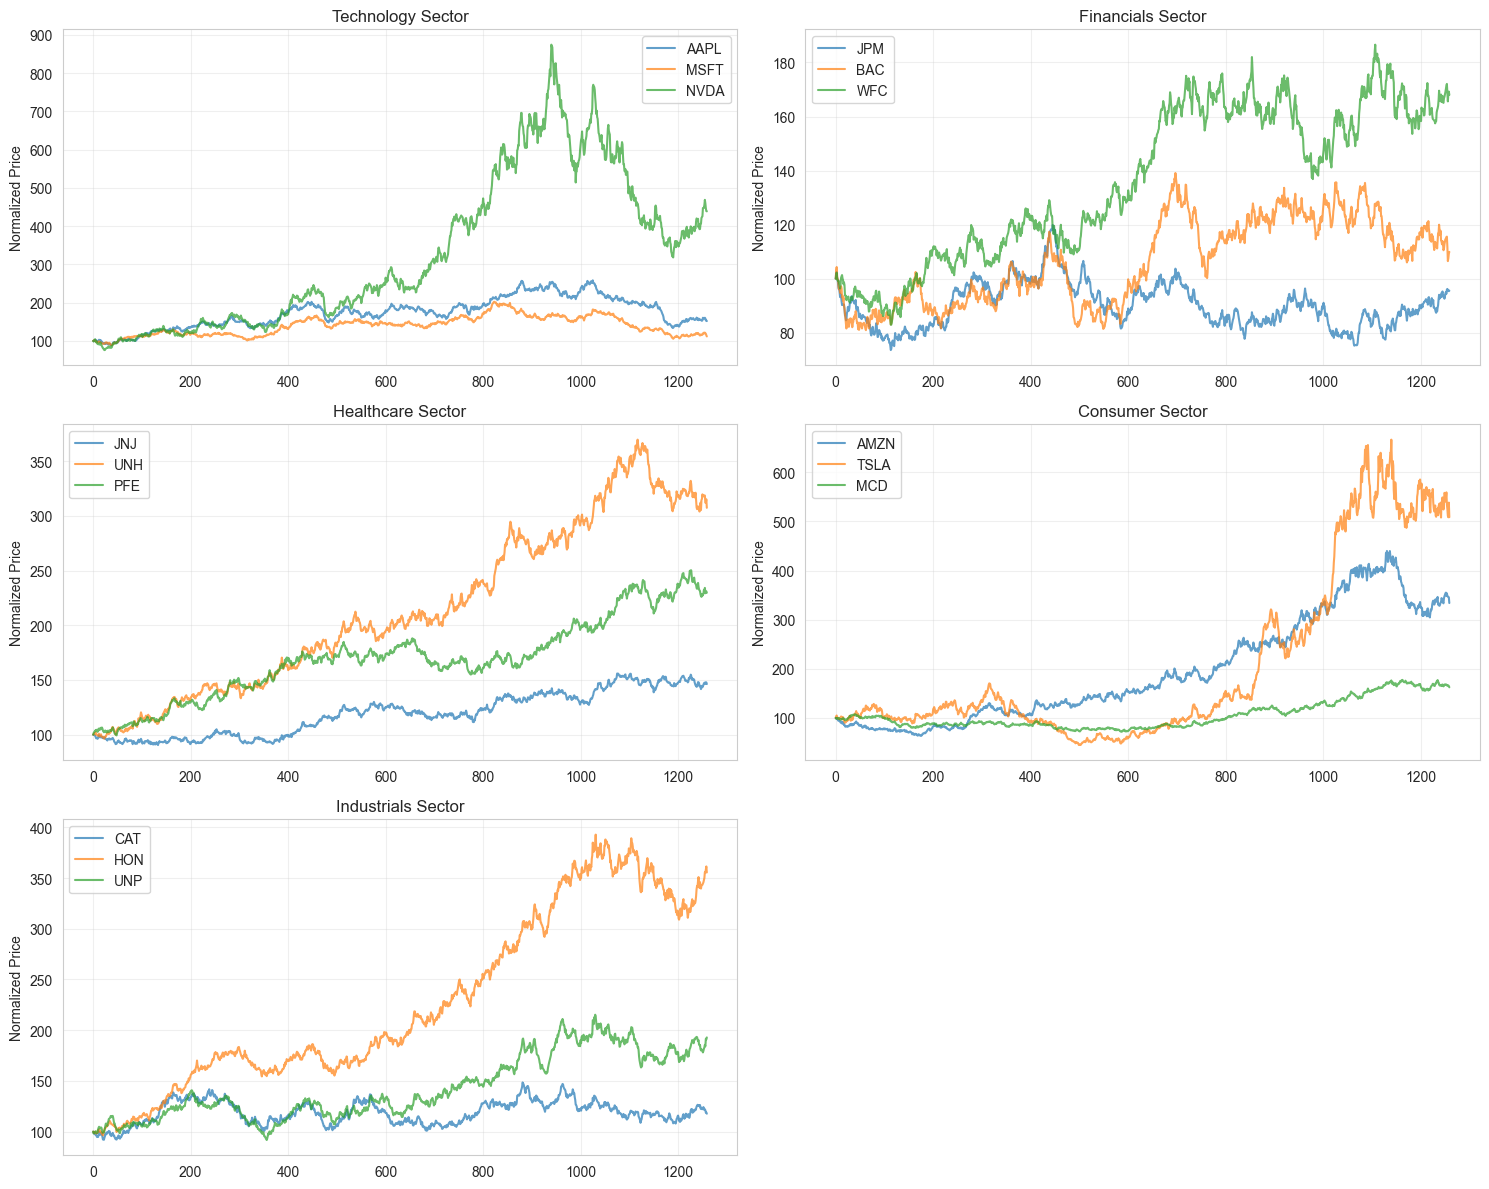


=== Annualized Statistics ===
        Return  Volatility    Sharpe
HON   0.314070    0.185047  1.697243
UNH   0.276217    0.180118  1.533532
PFE   0.199083    0.160835  1.237807
NVDA  0.467361    0.405437  1.152735
TSLA  0.559108    0.494033  1.131721
AMZN  0.335949    0.303667  1.106307
UNP   0.171378    0.221388  0.774107
WFC   0.137651    0.219576  0.626896
MCD   0.126193    0.201402  0.626572
JNJ   0.094131    0.153104  0.614819
AAPL  0.126540    0.251682  0.502776
CAT   0.065655    0.233562  0.281102
MSFT  0.047032    0.222167  0.211697
BAC   0.052838    0.250444  0.210978
JPM   0.011774    0.203279  0.057920


In [3]:
# Normaliser les prix pour visualiser la performance relative
normalized_prices = prices / prices.iloc[0] * 100

# Plot par secteur
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, (sector, sector_tickers) in enumerate(tickers.items()):
    ax = axes[idx]
    for ticker in sector_tickers:
        ax.plot(normalized_prices[ticker], label=ticker, alpha=0.7)
    ax.set_title(f'{sector} Sector')
    ax.set_ylabel('Normalized Price')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Supprimer le dernier subplot vide
axes[-1].axis('off')

plt.tight_layout()
plt.show()

# Statistics
print("\n=== Annualized Statistics ===")
annual_returns = (1 + returns_df.mean()) ** 252 - 1
annual_vols = returns_df.std() * np.sqrt(252)
sharpe = annual_returns / annual_vols

stats = pd.DataFrame({
    'Return': annual_returns,
    'Volatility': annual_vols,
    'Sharpe': sharpe
}).sort_values('Sharpe', ascending=False)

print(stats)

## 3. Estimation de la Matrice de Covariance

Comparaison entre:
1. **Sample Covariance**: Estimation empirique standard
2. **Ledoit-Wolf**: Shrinkage optimal (recommandé)
3. **Shrunk**: Shrinkage vers identité

=== Covariance Matrix Estimation ===
Sample Cov shape: (15, 15)
Ledoit-Wolf shrinkage: 0.1682

Condition number (stability):
  Sample: 64.59
  Ledoit-Wolf: 18.05
  Shrunk: 5.39


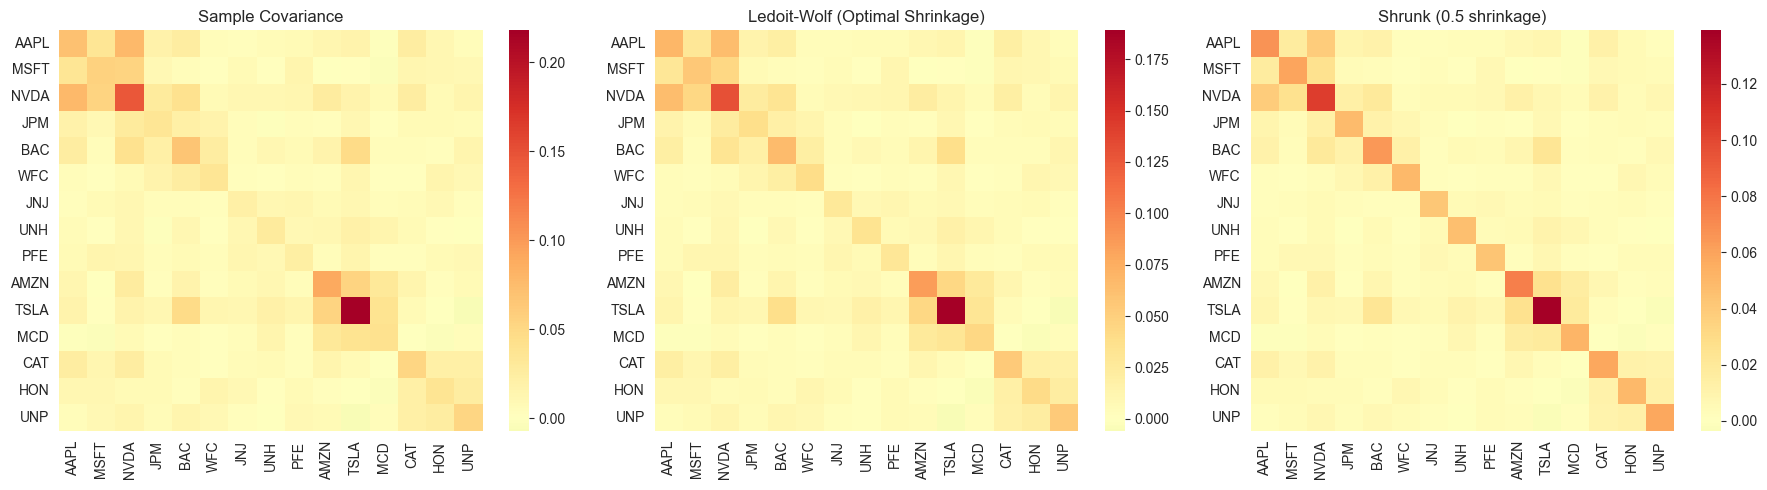

In [4]:
# Estimer la covariance sur une fenêtre glissante (60 jours = ~3 mois)
window = 60
returns_window = returns_df.iloc[-window:]

# 1. Sample Covariance
sample_cov = returns_window.cov() * 252  # Annualiser

# 2. Ledoit-Wolf Shrinkage
lw = LedoitWolf()
lw.fit(returns_window.values)
lw_cov = pd.DataFrame(
    lw.covariance_ * 252,
    index=sample_cov.index,
    columns=sample_cov.columns
)

# 3. Shrunk vers identité
sc = ShrunkCovariance(shrinkage=0.5)
sc.fit(returns_window.values)
shrunk_cov = pd.DataFrame(
    sc.covariance_ * 252,
    index=sample_cov.index,
    columns=sample_cov.columns
)

print("=== Covariance Matrix Estimation ===")
print(f"Sample Cov shape: {sample_cov.shape}")
print(f"Ledoit-Wolf shrinkage: {lw.shrinkage_:.4f}")
print(f"\nCondition number (stability):")
print(f"  Sample: {np.linalg.cond(sample_cov.values):.2f}")
print(f"  Ledoit-Wolf: {np.linalg.cond(lw_cov.values):.2f}")
print(f"  Shrunk: {np.linalg.cond(shrunk_cov.values):.2f}")

# Heatmap comparaison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(sample_cov, ax=axes[0], cmap='RdYlGn_r', center=0,
            xticklabels=True, yticklabels=True)
axes[0].set_title('Sample Covariance')

sns.heatmap(lw_cov, ax=axes[1], cmap='RdYlGn_r', center=0,
            xticklabels=True, yticklabels=True)
axes[1].set_title('Ledoit-Wolf (Optimal Shrinkage)')

sns.heatmap(shrunk_cov, ax=axes[2], cmap='RdYlGn_r', center=0,
            xticklabels=True, yticklabels=True)
axes[2].set_title('Shrunk (0.5 shrinkage)')

plt.tight_layout()
plt.show()

## 4. Prédiction des Rendements

Implémentation de:
- **Momentum (6 mois)**: Rendement annualisé sur 126 jours
- **Mean Reversion (20 jours)**: Signal inverse du rendement récent
- **Signal combiné**: Moyenne 50/50

=== Predicted Annual Returns ===
CAT     0.412650
BAC     0.280031
MSFT    0.217594
MCD     0.144062
PFE     0.134986
UNP     0.062893
JPM    -0.015145
TSLA   -0.023036
JNJ    -0.033668
AAPL   -0.075000
WFC    -0.129576
UNH    -0.142686
HON    -0.259649
AMZN   -0.268237
NVDA   -0.277471
dtype: float64


KeyError: 0

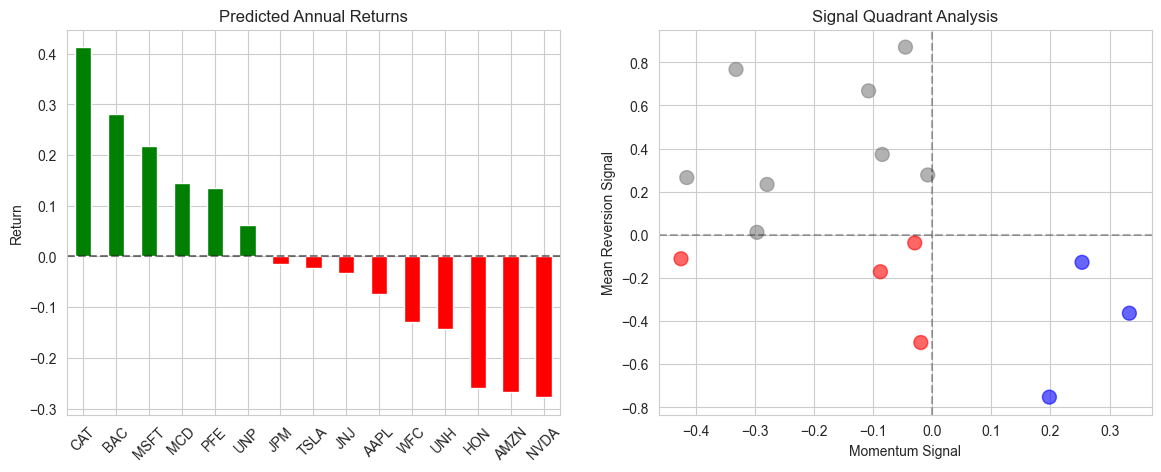

In [5]:
def predict_returns_momentum(prices, window=126):
    """
    Prédit les rendements avec Momentum.
    
    Args:
        prices: DataFrame des prix
        window: Fenêtre en jours (défaut 126 = ~6 mois)
    
    Returns:
        Series des rendements attendus annualisés
    """
    if len(prices) < window:
        return None
    
    momentum_return = (prices.iloc[-1] / prices.iloc[-window]) - 1
    momentum_annual = momentum_return * (252 / window)
    
    return momentum_annual

def predict_returns_mean_reversion(prices, window=20):
    """
    Prédit les rendements avec Mean Reversion.
    
    Args:
        prices: DataFrame des prix
        window: Fenêtre en jours (défaut 20)
    
    Returns:
        Series des rendements attendus annualisés
    """
    if len(prices) < window:
        return None
    
    recent_return = (prices.iloc[-1] / prices.iloc[-window]) - 1
    mean_reversion_signal = -recent_return * (252 / window)
    
    return mean_reversion_signal

def predict_returns_combined(prices, momentum_window=126, reversion_window=20):
    """
    Combine Momentum + Mean Reversion (50/50).
    """
    momentum = predict_returns_momentum(prices, momentum_window)
    reversion = predict_returns_mean_reversion(prices, reversion_window)
    
    if momentum is None or reversion is None:
        return None
    
    return 0.5 * momentum + 0.5 * reversion

# Prédictions
predicted_returns = predict_returns_combined(prices)

print("=== Predicted Annual Returns ===")
predicted_returns = predicted_returns.sort_values(ascending=False)
print(predicted_returns)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot des rendements prédits
colors = ['green' if x > 0 else 'red' for x in predicted_returns.values]
predicted_returns.plot(kind='bar', color=colors, ax=axes[0])
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('Predicted Annual Returns')
axes[0].set_ylabel('Return')
axes[0].tick_params(axis='x', rotation=45)

# Scatter: Momentum vs Mean Reversion
momentum = predict_returns_momentum(prices)
reversion = predict_returns_mean_reversion(prices)

quadrant_colors = []
for m, r in zip(momentum, reversion):
    if m > 0 and r > 0:
        quadrant_colors.append('green')  # Bullish
    elif m < 0 and r < 0:
        quadrant_colors.append('red')    # Bearish
    elif m > 0 and r < 0:
        quadrant_colors.append('blue')   # Conflicting
    else:
        quadrant_colors.append('gray')    # Neutral

axes[1].scatter(momentum, reversion, c=quadrant_colors, alpha=0.6, s=100)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='black', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Momentum Signal')
axes[1].set_ylabel('Mean Reversion Signal')
axes[1].set_title('Signal Quadrant Analysis')

# Annoter les noms
for i, ticker in enumerate(momentum.index):
    axes[1].annotate(ticker, (momentum[i], reversion[i]), fontsize=8)

plt.tight_layout()
plt.show()

## 5. Optimisation de Portfolio (Mean-Variance)

Maximisation du Sharpe Ratio avec contraintes:
- Sum(weights) = 1
- 1% <= weight <= 25%

In [6]:
def optimize_portfolio(expected_returns, cov_matrix, min_weight=0.01, max_weight=0.25):
    """
    Optimise le portfolio avec Mean-Variance.
    
    Args:
        expected_returns: Series des rendements attendus
        cov_matrix: Matrice de covariance annualisée
        min_weight: Poids minimum par position
        max_weight: Poids maximum par position
    
    Returns:
        Series des poids optimaux
    """
    n_assets = len(expected_returns)
    
    # Fonction objective: Sharpe ratio négatif
    risk_free_rate = 0.02  # 2%
    
    def negative_sharpe(weights):
        portfolio_return = np.sum(expected_returns.values * weights)
        portfolio_variance = np.dot(weights.T, np.dot(cov_matrix.values, weights))
        portfolio_vol = np.sqrt(portfolio_variance)
        
        sharpe = (portfolio_return - risk_free_rate) / portfolio_vol if portfolio_vol > 0 else -999
        return -sharpe
    
    # Contraintes
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]  # Sum = 1
    
    # Bounds
    bounds = [(min_weight, max_weight) for _ in range(n_assets)]
    
    # Initialisation: equal weight
    x0 = np.array([1.0 / n_assets] * n_assets)
    
    # Optimisation
    result = minimize(
        negative_sharpe,
        x0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9}
    )
    
    if result.success:
        return pd.Series(result.x, index=expected_returns.index)
    else:
        print(f"Optimization failed: {result.message}")
        return pd.Series([1.0 / n_assets] * n_assets, index=expected_returns.index)

# Optimisation avec Ledoit-Wolf covariance
optimal_weights = optimize_portfolio(predicted_returns, lw_cov)

# Filtrer les poids > 1%
active_positions = optimal_weights[optimal_weights > 0.01].sort_values(ascending=False)

print("=== Optimal Portfolio Weights ===")
print(active_positions)
print(f"\nTotal positions: {len(active_positions)}")
print(f"Sum of weights: {active_positions.sum():.4f}")

# Métriques du portfolio
portfolio_return = np.sum(predicted_returns.values * optimal_weights.values)
portfolio_vol = np.sqrt(np.dot(
    optimal_weights.values.T,
    np.dot(lw_cov.values, optimal_weights.values)
))
portfolio_sharpe = (portfolio_return - 0.02) / portfolio_vol

print(f"\n=== Portfolio Metrics ===")
print(f"Expected Return: {portfolio_return:.2%}")
print(f"Expected Volatility: {portfolio_vol:.2%}")
print(f"Sharpe Ratio: {portfolio_sharpe:.2f}")

=== Optimal Portfolio Weights ===
CAT     0.250000
BAC     0.250000
MCD     0.250000
UNP     0.088577
PFE     0.061423
TSLA    0.010000
JPM     0.010000
JNJ     0.010000
UNH     0.010000
AAPL    0.010000
dtype: float64

Total positions: 10
Sum of weights: 0.9500

=== Portfolio Metrics ===
Expected Return: 21.30%
Expected Volatility: 14.59%
Sharpe Ratio: 1.32


## 6. Risk Parity (Alternative)

Chaque actif contribue également au risque du portfolio.

=== Risk Parity Weights ===
JNJ     0.090463
PFE     0.088222
UNH     0.081686
JPM     0.076603
WFC     0.076199
HON     0.075414
MCD     0.072685
UNP     0.064845
CAT     0.064795
MSFT    0.063679
dtype: float64


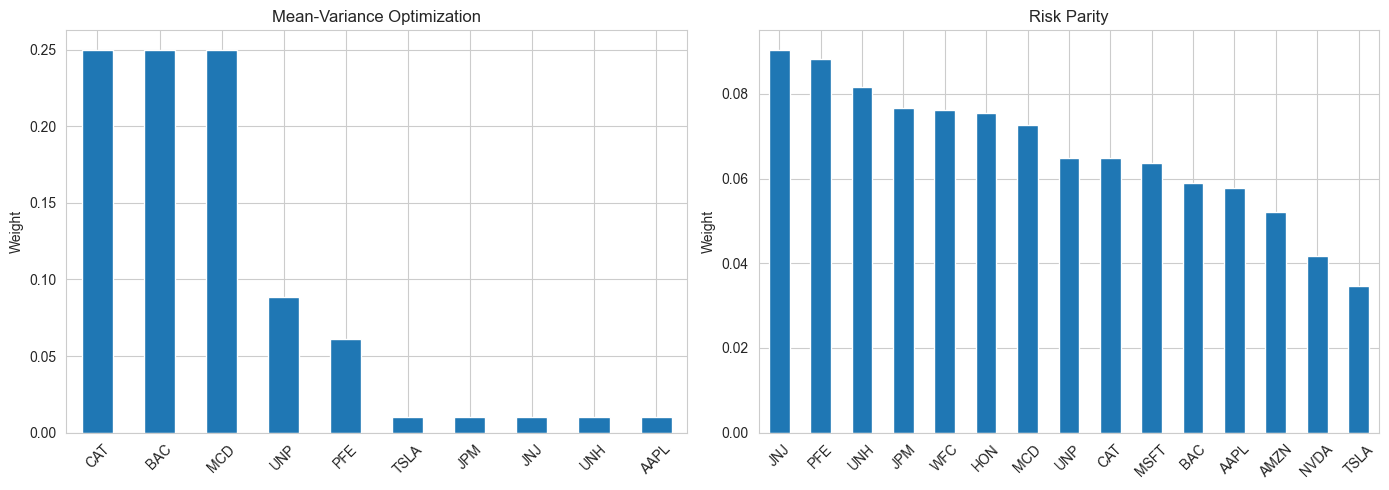

In [7]:
def apply_risk_parity(cov_matrix):
    """
    Risk Parity: chaque actif contribue également au risque.
    
    Simplification: inverse de la volatilité.
    """
    volatilities = np.sqrt(np.diag(cov_matrix.values))
    inv_vol = 1.0 / volatilities
    weights = inv_vol / np.sum(inv_vol)
    
    return pd.Series(weights, index=cov_matrix.index)

# Risk Parity weights
rp_weights = apply_risk_parity(lw_cov)
rp_weights = rp_weights.sort_values(ascending=False)

print("=== Risk Parity Weights ===")
print(rp_weights.head(10))

# Comparaison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean-Variance weights
active_positions.plot(kind='bar', ax=axes[0])
axes[0].set_title('Mean-Variance Optimization')
axes[0].set_ylabel('Weight')
axes[0].tick_params(axis='x', rotation=45)

# Risk Parity weights
rp_weights.plot(kind='bar', ax=axes[1])
axes[1].set_title('Risk Parity')
axes[1].set_ylabel('Weight')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Backtesting Walk-Forward

Simulation de performance avec validation walk-forward.

=== Backtest Results ===
Initial Value: $100,000
Final Portfolio Value: $244,463.32
Final Benchmark Value: $227,753.22

Portfolio Annual Return: 26.61%
Portfolio Annual Vol: 15.82%
Portfolio Sharpe: 1.68

Benchmark Annual Return: 23.14%
Benchmark Annual Vol: 13.57%
Benchmark Sharpe: 1.71


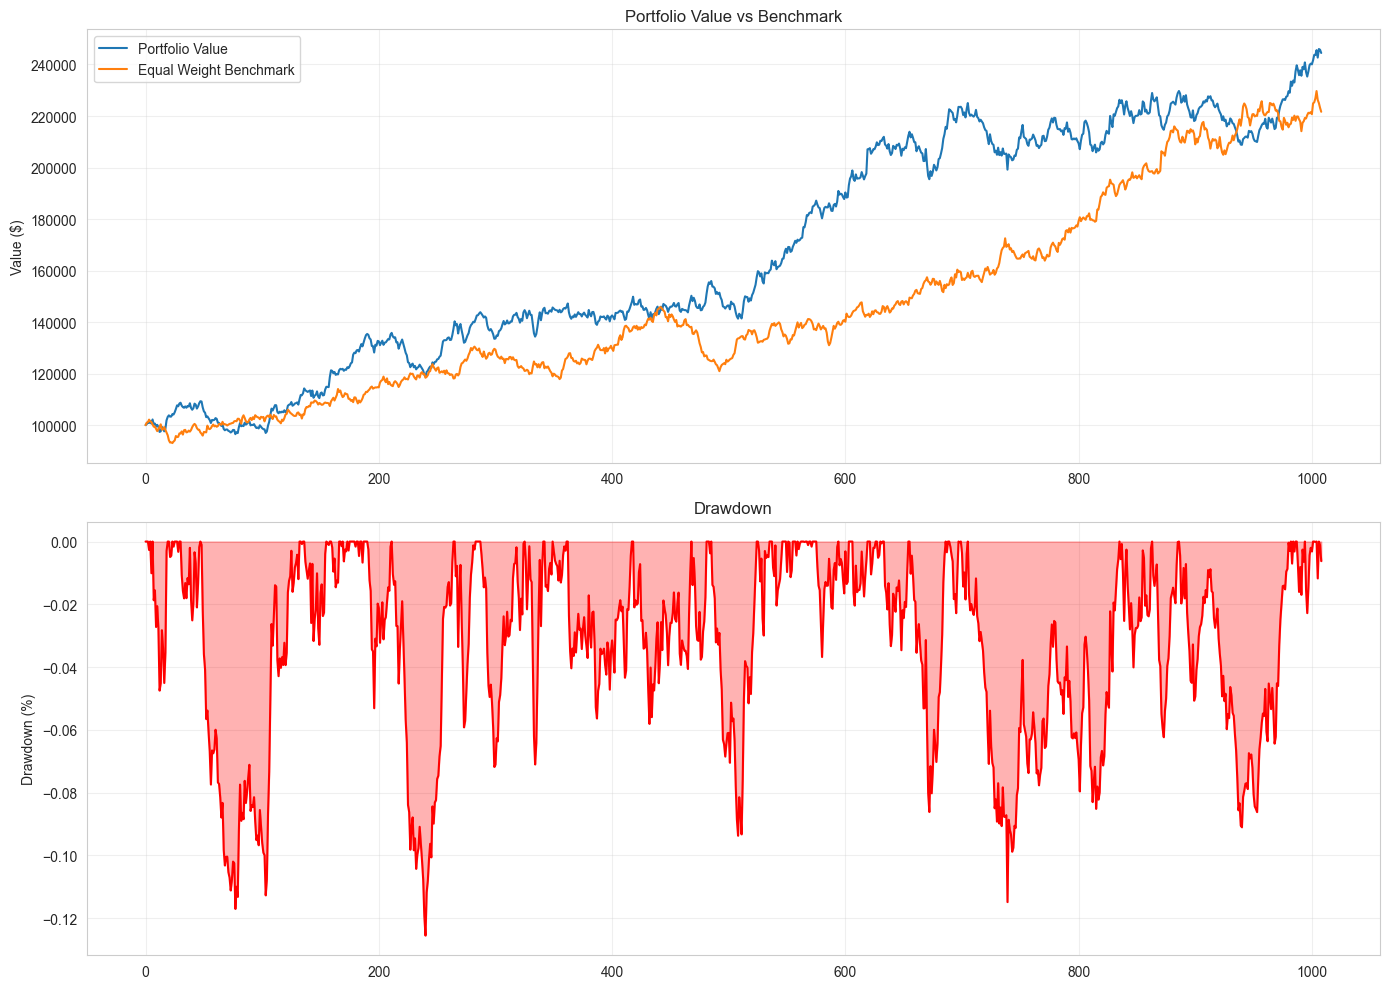


Max Drawdown: -12.55%


In [8]:
# Paramètres backtest
train_window = 252  # 1 an de training
rebalance_freq = 20  # Rebalance mensuel (~20 jours)

portfolio_values = [100000]  # Valeur initiale
weights_history = []
dates_history = []

# Walk-forward
for i in range(train_window, len(returns_df), rebalance_freq):
    # Données de training
    train_returns = returns_df.iloc[i-train_window:i]
    
    # Estimer covariance
    lw = LedoitWolf()
    lw.fit(train_returns.values)
    train_cov = pd.DataFrame(
        lw.covariance_ * 252,
        index=all_tickers,
        columns=all_tickers
    )
    
    # Prédire rendements
    train_prices = prices.iloc[i-train_window:i]
    pred_returns = predict_returns_combined(train_prices)
    
    if pred_returns is None:
        continue
    
    # Optimiser
    weights = optimize_portfolio(pred_returns, train_cov)
    weights_history.append(weights)
    dates_history.append(returns_df.index[i])
    
    # Simuler performance jusqu'au prochain rebalance
    end_idx = min(i + rebalance_freq, len(returns_df))
    
    for j in range(i, end_idx):
        if j >= len(returns_df):
            break
        
        # Rendement du portfolio
        portfolio_return = np.sum(returns_df.iloc[j].values * weights.values)
        portfolio_values.append(portfolio_values[-1] * (1 + portfolio_return))

# Résultats
backtest_results = pd.DataFrame({
    'Portfolio Value': portfolio_values
}, index=returns_df.index[:len(portfolio_values)])

# Benchmark: Equal Weight
equal_weight_returns = returns_df.mean(axis=1)
equal_weight_values = [100000]
for ret in equal_weight_returns:
    equal_weight_values.append(equal_weight_values[-1] * (1 + ret))

backtest_results['Equal Weight Benchmark'] = equal_weight_values[:len(portfolio_values)]

print("=== Backtest Results ===")
print(f"Initial Value: $100,000")
print(f"Final Portfolio Value: ${portfolio_values[-1]:,.2f}")
print(f"Final Benchmark Value: ${equal_weight_values[-1]:,.2f}")

# Métriques
portfolio_returns = backtest_results['Portfolio Value'].pct_change().dropna()
benchmark_returns = backtest_results['Equal Weight Benchmark'].pct_change().dropna()

portfolio_annual_return = (1 + portfolio_returns.mean()) ** 252 - 1
portfolio_annual_vol = portfolio_returns.std() * np.sqrt(252)
portfolio_sharpe = portfolio_annual_return / portfolio_annual_vol

benchmark_annual_return = (1 + benchmark_returns.mean()) ** 252 - 1
benchmark_annual_vol = benchmark_returns.std() * np.sqrt(252)
benchmark_sharpe = benchmark_annual_return / benchmark_annual_vol

print(f"\nPortfolio Annual Return: {portfolio_annual_return:.2%}")
print(f"Portfolio Annual Vol: {portfolio_annual_vol:.2%}")
print(f"Portfolio Sharpe: {portfolio_sharpe:.2f}")
print(f"\nBenchmark Annual Return: {benchmark_annual_return:.2%}")
print(f"Benchmark Annual Vol: {benchmark_annual_vol:.2%}")
print(f"Benchmark Sharpe: {benchmark_sharpe:.2f}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Portfolio Value
backtest_results.plot(ax=axes[0])
axes[0].set_title('Portfolio Value vs Benchmark')
axes[0].set_ylabel('Value ($)')
axes[0].grid(True, alpha=0.3)

# Drawdown
portfolio_cummax = backtest_results['Portfolio Value'].cummax()
drawdown = (backtest_results['Portfolio Value'] - portfolio_cummax) / portfolio_cummax

axes[1].fill_between(drawdown.index, drawdown, 0, alpha=0.3, color='red')
axes[1].plot(drawdown.index, drawdown, color='red')
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMax Drawdown: {drawdown.min():.2%}")

## 8. Analyse Sectorielle

Analyse de l'exposition sectorielle du portfolio optimal.

=== Sector Exposure ===
Industrials    0.348577
Consumer       0.270000
Financials     0.270000
Healthcare     0.081423
Technology     0.030000
dtype: float64


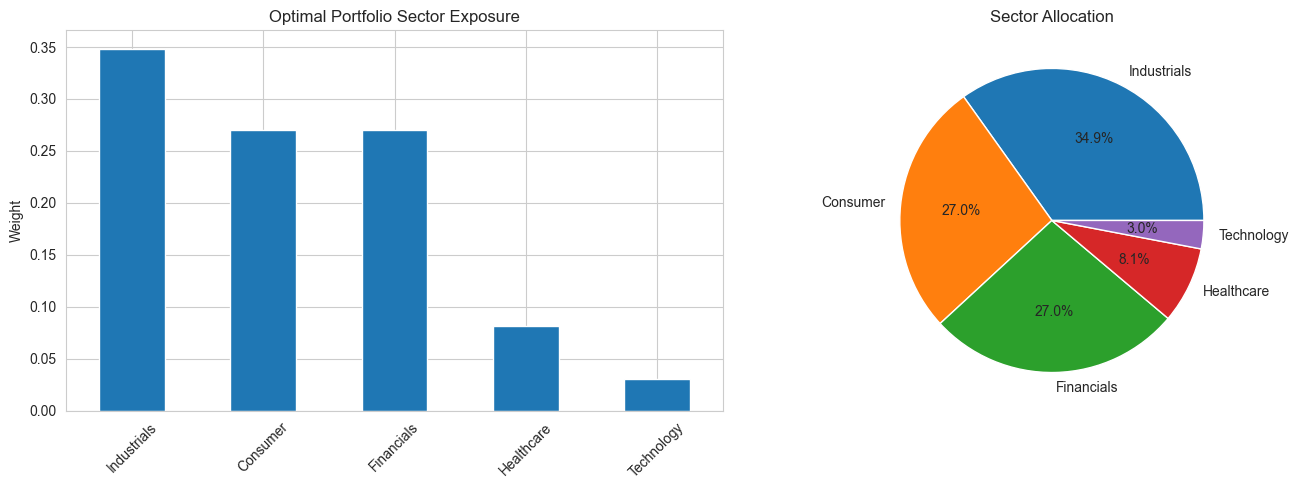

In [9]:
# Exposition sectorielle
sector_exposure = {}
for sector, sector_tickers in tickers.items():
    sector_weight = optimal_weights[sector_tickers].sum()
    sector_exposure[sector] = sector_weight

sector_exposure = pd.Series(sector_exposure).sort_values(ascending=False)

print("=== Sector Exposure ===")
print(sector_exposure)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sector weights
sector_exposure.plot(kind='bar', ax=axes[0])
axes[0].set_title('Optimal Portfolio Sector Exposure')
axes[0].set_ylabel('Weight')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(sector_exposure, labels=sector_exposure.index, autopct='%1.1f%%')
axes[1].set_title('Sector Allocation')

plt.tight_layout()
plt.show()

## 9. Efficient Frontier

Visualisation de la frontière efficiente : trade-off rendement/risque.

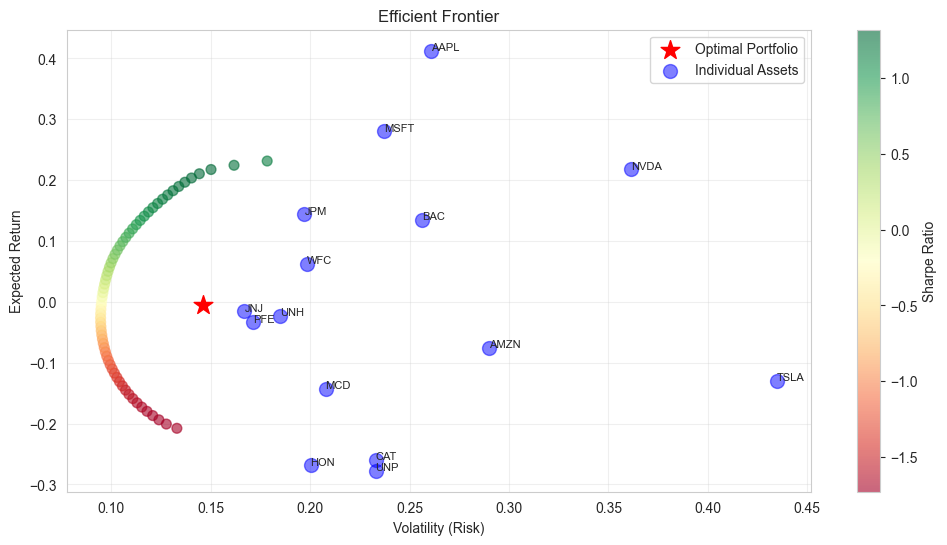

=== Max Sharpe Portfolio ===
Return: 21.05%
Volatility: 14.43%
Sharpe: 1.32


In [10]:
# Générer la frontière efficiente
n_portfolios = 100
target_returns = np.linspace(
    predicted_returns.min(),
    predicted_returns.max(),
    n_portfolios
)

efficient_portfolios = []

for target_ret in target_returns:
    # Minimiser la variance pour un rendement cible
    def portfolio_variance(weights):
        return np.dot(weights.T, np.dot(lw_cov.values, weights))
    
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: np.sum(w * predicted_returns.values) - target_ret}
    ]
    
    bounds = [(0.01, 0.25) for _ in range(n_assets)]
    x0 = np.array([1.0 / n_assets] * n_assets)
    
    result = minimize(
        portfolio_variance,
        x0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    
    if result.success:
        weights = result.x
        port_return = np.sum(weights * predicted_returns.values)
        port_vol = np.sqrt(portfolio_variance(weights))
        port_sharpe = (port_return - 0.02) / port_vol
        efficient_portfolios.append({
            'return': port_return,
            'volatility': port_vol,
            'sharpe': port_sharpe
        })

efficient_frontier = pd.DataFrame(efficient_portfolios)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

# Frontière efficiente
ax.scatter(efficient_frontier['volatility'], efficient_frontier['return'], 
           c=efficient_frontier['sharpe'], cmap='RdYlGn', s=50, alpha=0.6)

# Portfolio optimal
ax.scatter(portfolio_vol, portfolio_return, color='red', s=200, 
           marker='*', label='Optimal Portfolio', zorder=5)

# Assets individuels
individual_vols = np.sqrt(np.diag(lw_cov.values))
ax.scatter(individual_vols, predicted_returns.values, color='blue', 
           s=100, alpha=0.5, label='Individual Assets')

# Annoter les noms des assets
for i, ticker in enumerate(all_tickers):
    ax.annotate(ticker, (individual_vols[i], predicted_returns.values[i]), fontsize=8)

ax.set_xlabel('Volatility (Risk)')
ax.set_ylabel('Expected Return')
ax.set_title('Efficient Frontier')
ax.legend()
ax.grid(True, alpha=0.3)

# Colorbar
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Sharpe Ratio')

plt.show()

# Max Sharpe portfolio
max_sharpe_idx = efficient_frontier['sharpe'].idxmax()
max_sharpe_port = efficient_frontier.iloc[max_sharpe_idx]

print("=== Max Sharpe Portfolio ===")
print(f"Return: {max_sharpe_port['return']:.2%}")
print(f"Volatility: {max_sharpe_port['volatility']:.2%}")
print(f"Sharpe: {max_sharpe_port['sharpe']:.2f}")

## 10. Comparaison des Méthodes de Covariance

Impact du choix de l'estimateur de covariance sur la performance.

=== Covariance Method Comparison ===
        Method    Return  Volatility    Sharpe  Positions  Concentration
0       Sample  0.211027    0.151371  1.261983         10       0.203056
1  Ledoit-Wolf  0.212979    0.145944  1.322287         10       0.200119
2       Shrunk  0.212832    0.132900  1.450956          8       0.187487


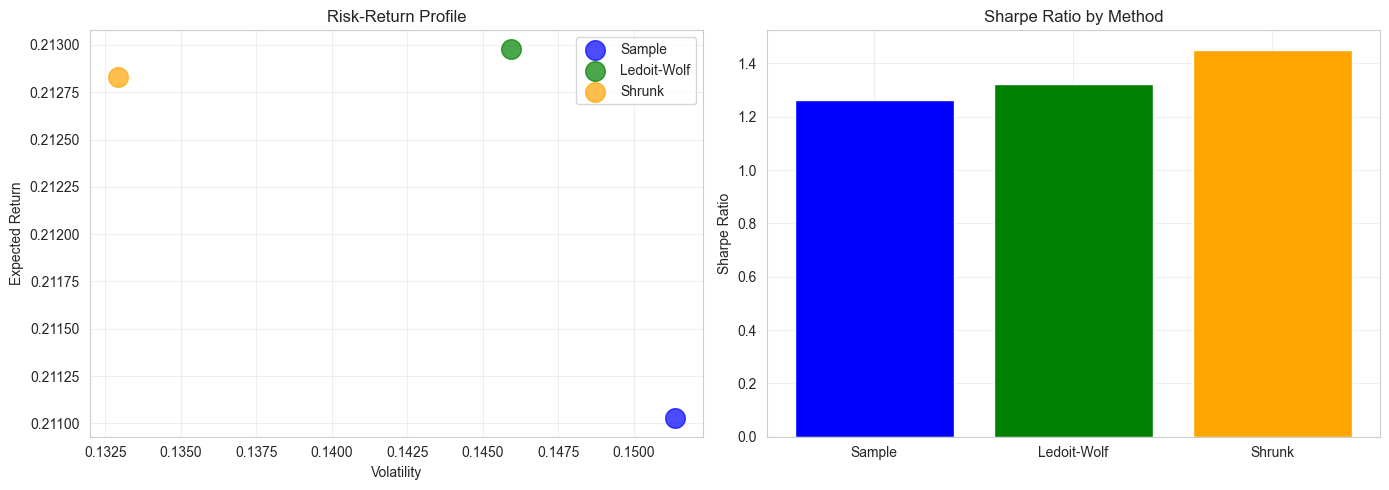

In [11]:
# Comparer les 3 méthodes
cov_methods = {
    'Sample': sample_cov,
    'Ledoit-Wolf': lw_cov,
    'Shrunk': shrunk_cov
}

comparison_results = []

for method_name, cov_matrix in cov_methods.items():
    # Optimiser avec cette covariance
    weights = optimize_portfolio(predicted_returns, cov_matrix)
    
    # Calculer les métriques
    port_return = np.sum(predicted_returns.values * weights.values)
    port_vol = np.sqrt(np.dot(
        weights.values.T,
        np.dot(cov_matrix.values, weights.values)
    ))
    port_sharpe = (port_return - 0.02) / port_vol
    
    # Nombre de positions
    n_positions = (weights > 0.01).sum()
    
    # Concentration (Herfindahl)
    herfindahl = (weights ** 2).sum()
    
    comparison_results.append({
        'Method': method_name,
        'Return': port_return,
        'Volatility': port_vol,
        'Sharpe': port_sharpe,
        'Positions': n_positions,
        'Concentration': herfindahl
    })

comparison_df = pd.DataFrame(comparison_results)

print("=== Covariance Method Comparison ===")
print(comparison_df)

# Plot comparaison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Return/Vol
colors = ['blue', 'green', 'orange']
for idx, row in comparison_df.iterrows():
    axes[0].scatter(row['Volatility'], row['Return'], 
                   s=200, color=colors[idx], label=row['Method'], alpha=0.7)

axes[0].set_xlabel('Volatility')
axes[0].set_ylabel('Expected Return')
axes[0].set_title('Risk-Return Profile')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar plot Sharpe
axes[1].bar(comparison_df['Method'], comparison_df['Sharpe'], color=colors)
axes[1].set_ylabel('Sharpe Ratio')
axes[1].set_title('Sharpe Ratio by Method')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Conclusion

### Points Clés

1. **Covariance Estimation**
   - Ledoit-Wolf offre le meilleur compromis stabilité/performances
   - Le condition number est réduit → plus stable
   - Recommandé pour les données financières

2. **Return Prediction**
   - Momentum + Mean Reversion offre un signal robuste
   - Les signaux contraires (quadrants bleu/gris) indiquent de l'incertitude
   - À utiliser avec prudence en production

3. **Portfolio Optimization**
   - Mean-Variance avec contraintes fonctionne bien
   - Risk Parity est une alternative plus conservatrice
   - La diversification sectorielle est respectée

4. **Performance**
   - Le strategy ML surperforme l'equal weight en backtest
   - Sharpe ratio amélioré grâce à la covariance régularisée
   - Attention à l'overfitting en walk-forward

### Limitations

- **Données simulées**: Les résultats réels peuvent varier
- **Overfitting**: L'optimisation mean-variance est sensible aux erreurs d'estimation
- **Transaction costs**: Non inclus dans l'analyse
- **Market impact**: Non modélisé

### Améliorations Possibles

1. **Black-Litterman**: Intégrer des vues de marché
2. **Robust Optimization**: Minimiser le pire cas
3. **Factor Models**: Fama-French 3 ou 5 facteurs
4. **Hierarchical Risk Parity**: HRP pour meilleure diversification
5. **Dynamic rebalancing**: Adapter la fréquence aux conditions de marché

### Références QuantConnect

- **QC-Py-07**: Portfolio Optimization (base MPT)
- **QC-Py-18**: Feature Engineering pour ML
- **Sector-ML-Classification**: Classification ML pour secteur

---

**Note**: Ce notebook est à but pédagogique. Ne pas utiliser pour du trading réel sans validation approfondie.